# Prueba de funcionamiento individual del modelo de detección de poses mediapipe de google

In [ ]:
from pathlib import Path
import cv2
import mediapipe as mp
import numpy as np
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from mediapipe.tasks.python.vision import RunningMode
 
MODEL_PATH  = Path("pose_landmarker_full.task")
IMAGEN_TEST = Path(r"X:\ISTS\Investigación\Chatbot Ergo\FOTOS\BIEN DE PIE\1.jpg")
 
NOMBRES_LM = [
    "nose","left_eye_inner","left_eye","left_eye_outer",
    "right_eye_inner","right_eye","right_eye_outer",
    "left_ear","right_ear","mouth_left","mouth_right",
    "left_shoulder","right_shoulder","left_elbow","right_elbow",
    "left_wrist","right_wrist","left_pinky","right_pinky",
    "left_index","right_index","left_thumb","right_thumb",
    "left_hip","right_hip","left_knee","right_knee",
    "left_ankle","right_ankle","left_heel","right_heel",
    "left_foot_index","right_foot_index",
]
 
CRITICOS = {11: "LEFT_SHOULDER", 12: "RIGHT_SHOULDER", 23: "LEFT_HIP", 24: "RIGHT_HIP"}
 
# Después:
img_bgr = cv2.imdecode(
    np.frombuffer(IMAGEN_TEST.read_bytes(), dtype=np.uint8),
    cv2.IMREAD_COLOR
)
if img_bgr is None:
    print(f"ERROR: No se pudo leer la imagen: {IMAGEN_TEST}")
    exit(1)
 
h, w = img_bgr.shape[:2]
print(f"Imagen: {IMAGEN_TEST.name}  ({w}x{h}px)")
 
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
 
base_options = mp_python.BaseOptions(model_asset_path=str(MODEL_PATH))
options = mp_vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=RunningMode.IMAGE,
    min_pose_detection_confidence=0.1,   
    min_pose_presence_confidence=0.1,
    min_tracking_confidence=0.1,
    num_poses=1,
)
 
with mp_vision.PoseLandmarker.create_from_options(options) as detector:
    resultado = detector.detect(mp_image)
 
if not resultado.pose_landmarks:
    print("\n⚠  MediaPipe NO detectó ninguna pose en esta imagen.")
    print("   Posibles causas:")
    print("   - La persona está muy recortada o de espaldas")
    print("   - La imagen es muy pequeña o de baja calidad")
    print("   - Prueba con otra foto más clara")
else:
    lm = resultado.pose_landmarks[0]
    print(f"\nPose detectada ✓  ({len(lm)} landmarks)\n")
    print(f"{'#':<4} {'Landmark':<22} {'visibility':>10}  {'presence':>10}   {'CRÍTICO?'}")
    print("-" * 68)
    for i, p in enumerate(lm):
        nombre = NOMBRES_LM[i] if i < len(NOMBRES_LM) else f"lm_{i}"
        critico = "  ← CRÍTICO" if i in CRITICOS else ""
        vis = p.visibility if p.visibility is not None else 0.0
        pre = p.presence  if p.presence  is not None else 0.0
        flag = "⚠ BAJO" if (i in CRITICOS and vis < 0.3) else ""
        print(f"{i:<4} {nombre:<22} {vis:>10.4f}  {pre:>10.4f}  {critico} {flag}")
 
    print("\n── Landmarks críticos ──────────────────────────────────────────")
    for idx, nombre in CRITICOS.items():
        vis = lm[idx].visibility or 0.0
        estado = "OK ✓" if vis >= 0.3 else "FALLA ✗  (< 0.3 — causa el None)"
        print(f"  {nombre:<20} visibility={vis:.4f}  →  {estado}")
 
    print("\n── Sugerencia ──────────────────────────────────────────────────")
    visibilidades = [lm[i].visibility or 0.0 for i in CRITICOS]
    min_vis = min(visibilidades)
    if min_vis < 0.3:
        umbral_sugerido = round(min_vis * 0.8, 2)
        print(f"  Baja el umbral en el script principal de 0.3 a {umbral_sugerido}")
        print(f'  Busca la línea:  if any(vis(i) < 0.3 for i in CRITICOS)')
        print(f'  Cámbiala por:    if any(vis(i) < {umbral_sugerido} for i in CRITICOS)')
    else:
        print("  Los landmarks críticos están OK. El problema puede ser otro.")
        print("  Corre el script principal con logging en DEBUG para ver errores por imagen.")

Imagen: 1.jpg  (1200x1600px)

Pose detectada ✓  (33 landmarks)

#    Landmark               visibility    presence   CRÍTICO?
--------------------------------------------------------------------
0    nose                       0.9968      0.9850   
1    left_eye_inner             0.9949      0.9801   
2    left_eye                   0.9923      0.9818   
3    left_eye_outer             0.9965      0.9828   
4    right_eye_inner            0.9959      0.9753   
5    right_eye                  0.9931      0.9728   
6    right_eye_outer            0.9954      0.9702   
7    left_ear                   0.9925      0.9855   
8    right_ear                  0.9935      0.9753   
9    mouth_left                 0.9977      0.9838   
10   mouth_right                0.9981      0.9788   
11   left_shoulder              0.9980      0.9993    ← CRÍTICO 
12   right_shoulder             0.9995      0.9953    ← CRÍTICO 
13   left_elbow                 0.0935      0.9996   
14   right_elbow           

# **Generación de csv con datos posturales de las fotos**

In [ ]:
import csv
import math
import logging
import sys
import time
from pathlib import Path
 
import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from mediapipe.tasks.python.vision import RunningMode
import numpy as np
 
FOTOS_DIR   = Path(r"X:\ISTS\Investigación\Chatbot Ergo\FOTOS")
MODEL_PATH  = Path("pose_landmarker_full.task")   # descárgalo (ver docstring arriba)
OUTPUT_CSV  = Path("dataset_posturas.csv")
OUTPUT_INFO = Path("dataset_info.txt")
 
CLASES = {
    "BIEN DE PIE":       0,
    "BIEN LEVANTANDO":   1,
    "BIEN SENTADOS":     2,
    "MAL DE PIE":        3,
    "MAL LEVANTANDO":    4,
    "MAL SENTADOS":      5,
}
 
EXTENSIONES_VALIDAS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
MP_DETECTION_CONFIDENCE = 0.4
 
LM = {
    "NOSE":             0,
    "LEFT_EYE":         2,
    "RIGHT_EYE":        5,
    "LEFT_EAR":         7,
    "RIGHT_EAR":        8,
    "LEFT_SHOULDER":   11,
    "RIGHT_SHOULDER":  12,
    "LEFT_ELBOW":      13,
    "RIGHT_ELBOW":     14,
    "LEFT_WRIST":      15,
    "RIGHT_WRIST":     16,
    "LEFT_HIP":        23,
    "RIGHT_HIP":       24,
    "LEFT_KNEE":       25,
    "RIGHT_KNEE":      26,
    "LEFT_ANKLE":      27,
    "RIGHT_ANKLE":     28,
    "LEFT_HEEL":       29,
    "RIGHT_HEEL":      30,
    "LEFT_FOOT_INDEX": 31,
    "RIGHT_FOOT_INDEX":32,
}
 
def angulo_entre_tres_puntos(A, B, C):
    BA = np.array(A[:2]) - np.array(B[:2])
    BC = np.array(C[:2]) - np.array(B[:2])
    cos_ang = np.dot(BA, BC) / (np.linalg.norm(BA) * np.linalg.norm(BC) + 1e-9)
    return math.degrees(math.acos(np.clip(cos_ang, -1.0, 1.0)))
 
def angulo_con_vertical(A, B):
    dx = B[0] - A[0]
    dy = B[1] - A[1]
    return math.degrees(math.atan2(abs(dx), abs(dy) + 1e-9))
 
def punto_medio(A, B):
    return [(A[0] + B[0]) / 2, (A[1] + B[1]) / 2]
 
def extraer_features(pose_landmarks, w, h):
    """
    pose_landmarks: lista de NormalizedLandmark de la nueva Tasks API.
    Cada landmark tiene: x, y, z (normalizados 0-1), visibility, presence.
    """
    lm = pose_landmarks
 
    def pt(idx):
        p = lm[idx]
        return [p.x * w, p.y * h, p.z]
 
    def vis(idx):
        return lm[idx].visibility if lm[idx].visibility is not None else 0.0
 
    CRITICOS = [LM["LEFT_SHOULDER"], LM["RIGHT_SHOULDER"], LM["LEFT_HIP"], LM["RIGHT_HIP"]]
    if any(vis(i) < 0.3 for i in CRITICOS):
        return None
 
    nariz       = pt(LM["NOSE"])
    hombro_izq  = pt(LM["LEFT_SHOULDER"])
    hombro_der  = pt(LM["RIGHT_SHOULDER"])
    cadera_izq  = pt(LM["LEFT_HIP"])
    cadera_der  = pt(LM["RIGHT_HIP"])
    rodilla_izq = pt(LM["LEFT_KNEE"])
    rodilla_der = pt(LM["RIGHT_KNEE"])
    tobillo_izq = pt(LM["LEFT_ANKLE"])
    tobillo_der = pt(LM["RIGHT_ANKLE"])
    codo_izq    = pt(LM["LEFT_ELBOW"])
    codo_der    = pt(LM["RIGHT_ELBOW"])
    muneca_izq  = pt(LM["LEFT_WRIST"])
    muneca_der  = pt(LM["RIGHT_WRIST"])
 
    centro_hombros = punto_medio(hombro_izq, hombro_der)
    centro_caderas = punto_medio(cadera_izq, cadera_der)
    ref = np.linalg.norm(np.array(centro_hombros[:2]) - np.array(centro_caderas[:2])) + 1e-9
 
    angulos = {
        "inclinacion_columna":    round(angulo_con_vertical(centro_hombros, centro_caderas), 4),
        "angulo_cuello":          round(angulo_entre_tres_puntos(nariz, centro_hombros, centro_caderas), 4),
        "ang_rodilla_izq":        round(angulo_entre_tres_puntos(cadera_izq, rodilla_izq, tobillo_izq), 4)
                                  if vis(LM["LEFT_KNEE"]) > 0.3 and vis(LM["LEFT_ANKLE"]) > 0.3 else -1.0,
        "ang_rodilla_der":        round(angulo_entre_tres_puntos(cadera_der, rodilla_der, tobillo_der), 4)
                                  if vis(LM["RIGHT_KNEE"]) > 0.3 and vis(LM["RIGHT_ANKLE"]) > 0.3 else -1.0,
        "ang_codo_izq":           round(angulo_entre_tres_puntos(hombro_izq, codo_izq, muneca_izq), 4)
                                  if vis(LM["LEFT_ELBOW"]) > 0.3 and vis(LM["LEFT_WRIST"]) > 0.3 else -1.0,
        "ang_codo_der":           round(angulo_entre_tres_puntos(hombro_der, codo_der, muneca_der), 4)
                                  if vis(LM["RIGHT_ELBOW"]) > 0.3 and vis(LM["RIGHT_WRIST"]) > 0.3 else -1.0,
        "inclinacion_hombros":    round(angulo_con_vertical(hombro_izq, hombro_der), 4),
        "inclinacion_caderas":    round(angulo_con_vertical(cadera_izq, cadera_der), 4),
        "ang_cadera_izq":         round(angulo_entre_tres_puntos(hombro_izq, cadera_izq, rodilla_izq), 4)
                                  if vis(LM["LEFT_HIP"]) > 0.3 and vis(LM["LEFT_KNEE"]) > 0.3 else -1.0,
        "ang_cadera_der":         round(angulo_entre_tres_puntos(hombro_der, cadera_der, rodilla_der), 4)
                                  if vis(LM["RIGHT_HIP"]) > 0.3 and vis(LM["RIGHT_KNEE"]) > 0.3 else -1.0,
        "adelanto_cabeza":        round((nariz[0] - centro_hombros[0]) / ref, 6),
        "altura_cadera_relativa": round((centro_caderas[1] - tobillo_izq[1]) / (h + 1e-9), 6)
                                  if vis(LM["LEFT_ANKLE"]) > 0.3
                                  else round((centro_caderas[1] - tobillo_der[1]) / (h + 1e-9), 6),
        "asimetria_hombros":      round(abs(hombro_izq[1] - hombro_der[1]) / ref, 6),
    }
 
    cx, cy = centro_caderas[0], centro_caderas[1]
    keypoints_norm = {}
    for nombre, idx in LM.items():
        p = lm[idx]
        keypoints_norm[f"kp_{nombre.lower()}_x"] = round((p.x * w - cx) / ref, 6)
        keypoints_norm[f"kp_{nombre.lower()}_y"] = round((p.y * h - cy) / ref, 6)
 
    landmarks_principales = [LM["NOSE"], LM["LEFT_SHOULDER"], LM["RIGHT_SHOULDER"],
                              LM["LEFT_HIP"], LM["RIGHT_HIP"], LM["LEFT_KNEE"], LM["RIGHT_KNEE"]]
    vis_promedio = round(float(np.mean([vis(i) for i in landmarks_principales])), 4)
 
    return {**angulos, **keypoints_norm, "visibilidad_promedio": vis_promedio}
 
def procesar_dataset():
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s  %(levelname)-8s  %(message)s",
        datefmt="%H:%M:%S",
    )
    log = logging.getLogger()
 
    if not FOTOS_DIR.exists():
        log.error(f"No se encontró la carpeta: {FOTOS_DIR.resolve()}")
        sys.exit(1)
 
    if not MODEL_PATH.exists():
        log.error(f"No se encontró el modelo: {MODEL_PATH.resolve()}")
        log.error("Descárgalo desde:")
        log.error("https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task")
        sys.exit(1)
 
    base_options = mp_python.BaseOptions(model_asset_path=str(MODEL_PATH))
    options = mp_vision.PoseLandmarkerOptions(
        base_options=base_options,
        running_mode=RunningMode.IMAGE,
        min_pose_detection_confidence=MP_DETECTION_CONFIDENCE,
        min_pose_presence_confidence=MP_DETECTION_CONFIDENCE,
        min_tracking_confidence=MP_DETECTION_CONFIDENCE,
        num_poses=1,
    )
 
    filas      = []
    columnas   = None
    stats      = {c: {"ok": 0, "sin_pose": 0, "error": 0} for c in CLASES}
    tiempo_ini = time.time()
 
    with mp_vision.PoseLandmarker.create_from_options(options) as detector:
 
        for nombre_clase, etiqueta in CLASES.items():
            carpeta = FOTOS_DIR / nombre_clase
            if not carpeta.exists():
                log.warning(f"Carpeta no encontrada, se omite: {carpeta}")
                continue
 
            archivos = [f for f in carpeta.iterdir() if f.suffix.lower() in EXTENSIONES_VALIDAS]
            if not archivos:
                log.warning(f"Sin imágenes en: {carpeta}")
                continue
 
            log.info(f"Procesando [{nombre_clase}] — {len(archivos)} imágenes")
 
            for ruta in archivos:
                try:
                    img_bgr = cv2.imdecode(
                    np.frombuffer(ruta.read_bytes(), dtype=np.uint8),
                    cv2.IMREAD_COLOR
                    )
                    if img_bgr is None:
                        stats[nombre_clase]["error"] += 1
                        continue
 
                    h, w = img_bgr.shape[:2]
                    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
 
                    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
                    resultado = detector.detect(mp_image)
 
                    if not resultado.pose_landmarks:
                        log.debug(f"  Sin pose: {ruta.name}")
                        stats[nombre_clase]["sin_pose"] += 1
                        continue
 
                    features = extraer_features(resultado.pose_landmarks[0], w, h)
                    if features is None:
                        log.debug(f"  Landmarks críticos no visibles: {ruta.name}")
                        stats[nombre_clase]["sin_pose"] += 1
                        continue
 
                    if columnas is None:
                        columnas = list(features.keys()) + ["clase_nombre", "clase_id", "archivo"]
 
                    filas.append(list(features.values()) + [nombre_clase, etiqueta, ruta.name])
                    stats[nombre_clase]["ok"] += 1
 
                except Exception as e:
                    log.warning(f"  Error en {ruta.name}: {e}")
                    stats[nombre_clase]["error"] += 1
 
    if not filas:
        log.error("No se extrajo ninguna fila. Revisa rutas y formato de imágenes.")
        sys.exit(1)
 
    with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(columnas)
        writer.writerows(filas)
 
    tiempo_total = time.time() - tiempo_ini
    lineas = [
        "=" * 60,
        "  RESUMEN DE EXTRACCIÓN DE KEYPOINTS",
        "=" * 60,
        f"  Tiempo total:    {tiempo_total:.1f} s",
        f"  Archivo salida:  {OUTPUT_CSV.resolve()}",
        f"  Total filas CSV: {len(filas)}",
        f"  Columnas:        {len(columnas)}",
        "",
        "  Por clase:",
    ]
    for clase, s in stats.items():
        total = s["ok"] + s["sin_pose"] + s["error"]
        if total == 0:
            continue
        lineas.append(f"    {clase:<22} ok={s['ok']:>4}  sin_pose={s['sin_pose']:>4}  error={s['error']:>3}  total={total:>4}")
    lineas.append("=" * 60)
 
    reporte = "\n".join(lineas)
    print("\n" + reporte)
    with open(OUTPUT_INFO, "w", encoding="utf-8") as f:
        f.write(reporte + "\n")
 
    log.info(f"CSV guardado en: {OUTPUT_CSV.resolve()}")
 
if __name__ == "__main__":
    procesar_dataset()

11:11:46  INFO      Procesando [BIEN DE PIE] — 620 imágenes
11:13:24  INFO      Procesando [BIEN LEVANTANDO] — 82 imágenes
11:13:33  INFO      Procesando [BIEN SENTADOS] — 258 imágenes
11:14:03  INFO      Procesando [MAL DE PIE] — 588 imágenes
11:18:10  INFO      Procesando [MAL LEVANTANDO] — 87 imágenes
11:18:23  INFO      Procesando [MAL SENTADOS] — 283 imágenes
11:19:31  INFO      CSV guardado en: X:\ISTS\Investigación\Chatbot Ergo\Python\Generación del modelo\dataset_posturas.csv



  RESUMEN DE EXTRACCIÓN DE KEYPOINTS
  Tiempo total:    465.1 s
  Archivo salida:  X:\ISTS\Investigación\Chatbot Ergo\Python\Generación del modelo\dataset_posturas.csv
  Total filas CSV: 1893
  Columnas:        59

  Por clase:
    BIEN DE PIE            ok= 612  sin_pose=   8  error=  0  total= 620
    BIEN LEVANTANDO        ok=  81  sin_pose=   1  error=  0  total=  82
    BIEN SENTADOS          ok= 255  sin_pose=   3  error=  0  total= 258
    MAL DE PIE             ok= 581  sin_pose=   7  error=  0  total= 588
    MAL LEVANTANDO         ok=  83  sin_pose=   4  error=  0  total=  87
    MAL SENTADOS           ok= 281  sin_pose=   2  error=  0  total= 283


# **Entrenamiento de la red neuronal con el archivo de puntos de posturas**

In [ ]:
"""
Entrenamiento simple — un solo modelo MLP.

Entrada:  dataset_posturas.csv
Salida:
    modelo_posturas.keras
    modelo_posturas.tflite
    scaler.pkl
    label_encoder.pkl
    reporte_entrenamiento.txt
    curvas_entrenamiento.png
"""

import pickle, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

CSV_PATH      = Path("dataset_posturas.csv")
MODELO_KERAS  = Path("modelo_posturas.keras")
MODELO_TFLITE = Path("modelo_posturas.tflite")
SCALER_PATH   = Path("scaler.pkl")
ENCODER_PATH  = Path("label_encoder.pkl")
REPORTE_PATH  = Path("reporte_entrenamiento.txt")
GRAFICA_PATH  = Path("curvas_entrenamiento.png")

EPOCHS      = 200
BATCH_SIZE  = 32
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15
SEED        = 42

print("=" * 55)
print("  ENTRENAMIENTO — CLASIFICADOR DE POSTURAS")
print("=" * 55)

df = pd.read_csv(CSV_PATH)
print(f"\nDataset: {len(df)} filas")
print(df["clase_nombre"].value_counts().to_string())

cols_angulos   = [c for c in df.columns if c.startswith("ang") or
                  c.startswith("inclin") or c.startswith("adelanto") or
                  c.startswith("altura") or c.startswith("asim")]
cols_keypoints = [c for c in df.columns if c.startswith("kp_")]
feature_cols   = cols_angulos + cols_keypoints + ["visibilidad_promedio"]

X = df[feature_cols].values.astype(np.float32)
y_nombres = df["clase_nombre"].values

le = LabelEncoder()
y  = le.fit_transform(y_nombres)
n_clases = len(le.classes_)

for i in range(X.shape[1]):
    for clase_id in np.unique(y):
        mask_clase = y == clase_id
        col_clase  = X[mask_clase, i]
        validos    = col_clase[col_clase != -1.0]
        med = float(np.median(validos)) if len(validos) > 0 else 0.0
        X[mask_clase & (X[:, i] == -1.0), i] = med

print(f"\nClases: {list(le.classes_)}")
print(f"Features: {X.shape[1]}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    random_state=SEED, stratify=y_train
)
print(f"\nSplit → train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Class weights
cw_array = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
cw = dict(enumerate(cw_array))
print(f"\nClass weights: { {le.classes_[k]: round(v,2) for k,v in cw.items()} }")

reg = regularizers.l2(0.001)

modelo = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(256, kernel_regularizer=reg),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.4),

    layers.Dense(128, kernel_regularizer=reg),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Dense(64, kernel_regularizer=reg),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    layers.Dense(n_clases, activation="softmax"),
], name="clasificador_posturas")

modelo.summary()

modelo.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=25,
        restore_best_weights=True, verbose=1
    )
]

print(f"\nEntrenando (máx {EPOCHS} épocas)...")
t0 = time.time()

hist = modelo.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=cw,
    callbacks=callbacks,
    verbose=1,
)

tiempo = time.time() - t0
epocas = len(hist.history["loss"])
print(f"\nListo en {tiempo:.1f}s ({epocas} épocas)")

loss_test, acc_test = modelo.evaluate(X_test, y_test, verbose=0)
y_pred = np.argmax(modelo.predict(X_test, verbose=0), axis=1)
reporte = classification_report(y_test, y_pred, target_names=le.classes_, digits=4)
cm      = confusion_matrix(y_test, y_pred)

print(f"\nTest Loss:     {loss_test:.4f}")
print(f"Test Accuracy: {acc_test*100:.2f}%")
print(f"\n{reporte}")
print("Matriz de confusión:")
print(cm)

modelo.save(str(MODELO_KERAS))

with open(SCALER_PATH, "wb") as f:
    pickle.dump(scaler, f)
with open(ENCODER_PATH, "wb") as f:
    pickle.dump(le, f)

print(f"\nModelo:  {MODELO_KERAS}")
print(f"Scaler:  {SCALER_PATH}")
print(f"Encoder: {ENCODER_PATH}")

# TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(modelo)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
with open(MODELO_TFLITE, "wb") as f:
    f.write(converter.convert())
print(f"TFLite:  {MODELO_TFLITE}  ({MODELO_TFLITE.stat().st_size/1024:.1f} KB)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Curvas de entrenamiento", fontsize=13)

ax1.plot(hist.history["loss"],     label="train")
ax1.plot(hist.history["val_loss"], label="val")
ax1.set_title("Loss"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot([v*100 for v in hist.history["accuracy"]],     label="train")
ax2.plot([v*100 for v in hist.history["val_accuracy"]], label="val")
ax2.set_title("Accuracy (%)"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(GRAFICA_PATH), dpi=150, bbox_inches="tight")
print(f"Gráfica: {GRAFICA_PATH}")

lineas = [
    "=" * 55,
    "  REPORTE — CLASIFICADOR DE POSTURAS",
    "=" * 55,
    f"  Features:      {X.shape[1]}",
    f"  Train:         {len(X_train)}",
    f"  Val:           {len(X_val)}",
    f"  Test:          {len(X_test)}",
    f"  Épocas reales: {epocas}",
    f"  Tiempo:        {tiempo:.1f}s",
    f"  Test Loss:     {loss_test:.4f}",
    f"  Test Accuracy: {acc_test*100:.2f}%",
    "", "  Classification report:", reporte,
    "  Matriz de confusión:", str(list(le.classes_)), str(cm),
    "=" * 55,
]
txt = "\n".join(lineas)
with open(REPORTE_PATH, "w", encoding="utf-8") as f:
    f.write(txt + "\n")
print(f"\nReporte: {REPORTE_PATH}")
print("\n" + txt)

  ENTRENAMIENTO — CLASIFICADOR DE POSTURAS

Dataset: 1893 filas
clase_nombre
BIEN DE PIE        612
MAL DE PIE         581
MAL SENTADOS       281
BIEN SENTADOS      255
MAL LEVANTANDO      83
BIEN LEVANTANDO     81

Clases: ['BIEN DE PIE', 'BIEN LEVANTANDO', 'BIEN SENTADOS', 'MAL DE PIE', 'MAL LEVANTANDO', 'MAL SENTADOS']
Features: 56

Split → train=1325  val=284  test=284

Class weights: {'BIEN DE PIE': np.float64(0.52), 'BIEN LEVANTANDO': np.float64(3.87), 'BIEN SENTADOS': np.float64(1.23), 'MAL DE PIE': np.float64(0.54), 'MAL LEVANTANDO': np.float64(3.87), 'MAL SENTADOS': np.float64(1.12)}


Model: "clasificador_posturas"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,670 (225.27 KB)

 Trainable params: 56,902 (222.27 KB)

...


Entrenando (máx 200 épocas)...
Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4845 - loss: 1.7113 - val_accuracy: 0.6901 - val_loss: 1.4104
Epoch 2/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6506 - loss: 1.2574 - val_accuracy: 0.7465 - val_loss: 1.1131
Epoch 3/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7019 - loss: 1.1166 - val_accuracy: 0.7570 - val_loss: 0.9790
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7200 - loss: 1.0946 - val_accuracy: 0.7782 - val_loss: 0.9267
Epoch 5/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7426 - loss: 1.0271 - val_accuracy: 0.7676 - val_loss: 0.8919
Epoch 6/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7298 - loss: 0.9979 - val_accuracy: 0.7958 - val_loss: 0.8665
Epoch 7/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7442 - loss: 0.9393 - val_accuracy: 0.7817 - val_loss: 0.8562
Epoch 8/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7668 - los

11:28:26  INFO      Function `function` contains input name(s) resource with unsupported characters which will be renamed to clasificador_posturas_1_dense_3_1_biasadd_readvariableop_resource in the SavedModel.
11:28:26  INFO      Function `function` contains input name(s) resource with unsupported characters which will be renamed to clasificador_posturas_1_dense_3_1_biasadd_readvariableop_resource in the SavedModel.


INFO:tensorflow:Assets written to: C:\Users\dapar\AppData\Local\Temp\tmpv_clzl5c\assets


11:28:27  INFO      Assets written to: C:\Users\dapar\AppData\Local\Temp\tmpv_clzl5c\assets


Saved artifact at 'C:\Users\dapar\AppData\Local\Temp\tmpv_clzl5c'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 56), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2186872906832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2186872908944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2186872907984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2186872908368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2186872908176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2186872907024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2186872906640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2186872909712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2186872909520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2186872909328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2186872907216:

# **Prueba de funcionamiento del modelo**

In [ ]:
import pickle, math
from pathlib import Path
import numpy as np
import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from mediapipe.tasks.python.vision import RunningMode
import tensorflow as tf
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

MODEL_PATH    = Path('pose_landmarker_full.task')
MODELO_KERAS  = Path('modelo_posturas.keras')
SCALER_PATH   = Path('scaler.pkl')
ENCODER_PATH  = Path('label_encoder.pkl')

with open(SCALER_PATH, 'rb') as f:
    scaler = pickle.load(f)
with open(ENCODER_PATH, 'rb') as f:
    le = pickle.load(f)

modelo = tf.keras.models.load_model(str(MODELO_KERAS))

print('✅ Modelos cargados')
print(f'   Clases: {list(le.classes_)}')
print(f'   Input shape: {modelo.input_shape}')

✅ Modelos cargados
   Clases: ['BIEN DE PIE', 'BIEN LEVANTANDO', 'BIEN SENTADOS', 'MAL DE PIE', 'MAL LEVANTANDO', 'MAL SENTADOS']
   Input shape: (None, 56)


In [ ]:
upload = widgets.FileUpload(
    accept='.jpg,.jpeg,.png,.bmp,.webp',
    multiple=False,
    description='📁 Seleccionar foto',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='250px')
)
estado = widgets.Label(value='Esperando foto...')
display(widgets.HBox([upload, estado]))

def on_upload(change):
    if upload.value:
        nombre = upload.value[0]['name']
        estado.value = f'✅ Foto cargada: {nombre}'

upload.observe(on_upload, names='value')

✅ Funciones listas


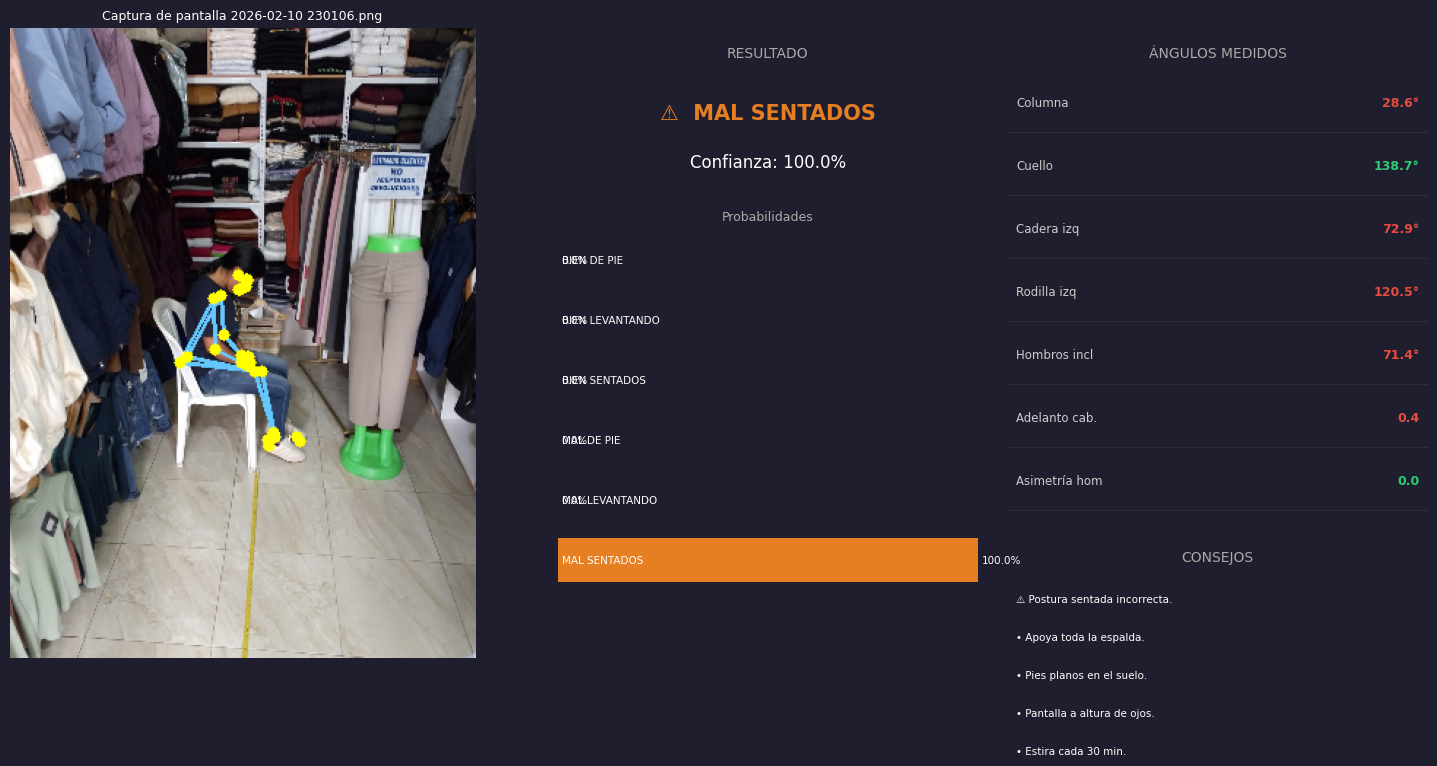


Clase: MAL SENTADOS  |  Confianza: 100.0%


In [ ]:
%matplotlib inline
LM = {
    'NOSE':0,'LEFT_EYE':2,'RIGHT_EYE':5,'LEFT_EAR':7,'RIGHT_EAR':8,
    'LEFT_SHOULDER':11,'RIGHT_SHOULDER':12,'LEFT_ELBOW':13,'RIGHT_ELBOW':14,
    'LEFT_WRIST':15,'RIGHT_WRIST':16,'LEFT_HIP':23,'RIGHT_HIP':24,
    'LEFT_KNEE':25,'RIGHT_KNEE':26,'LEFT_ANKLE':27,'RIGHT_ANKLE':28,
    'LEFT_HEEL':29,'RIGHT_HEEL':30,'LEFT_FOOT_INDEX':31,'RIGHT_FOOT_INDEX':32,
}
CONSEJOS = {
    'BIEN DE PIE':     ['✅ Postura de pie correcta.','Mantén hombros relajados y cabeza erguida.','Distribuye el peso en ambos pies.'],
    'BIEN LEVANTANDO': ['✅ Técnica de levantamiento correcta.','Rodillas dobladas y espalda recta.','Mantén el objeto cerca del cuerpo.'],
    'BIEN SENTADOS':   ['✅ Postura sentada correcta.','Espalda apoyada, pies planos en el suelo.','Pantalla a la altura de los ojos.'],
    'MAL DE PIE':      ['⚠️ Postura de pie incorrecta.','• Endereza la columna.','• Orejas sobre hombros.','• Activa el abdomen.','• Relaja los hombros.'],
    'MAL LEVANTANDO':  ['⚠️ Técnica incorrecta.','• Dobla las RODILLAS, no la espalda.','• Carga pegada al cuerpo.','• Mira adelante al levantarte.'],
    'MAL SENTADOS':    ['⚠️ Postura sentada incorrecta.','• Apoya toda la espalda.','• Pies planos en el suelo.','• Pantalla a altura de ojos.','• Estira cada 30 min.'],
}
COLORES = {
    'BIEN DE PIE':'#2ecc71','BIEN LEVANTANDO':'#27ae60','BIEN SENTADOS':'#1abc9c',
    'MAL DE PIE':'#e74c3c','MAL LEVANTANDO':'#c0392b','MAL SENTADOS':'#e67e22',
}

def ang3(A,B,C):
    BA=np.array(A[:2])-np.array(B[:2]); BC=np.array(C[:2])-np.array(B[:2])
    return math.degrees(math.acos(np.clip(np.dot(BA,BC)/(np.linalg.norm(BA)*np.linalg.norm(BC)+1e-9),-1,1)))
def angv(A,B):
    return math.degrees(math.atan2(abs(B[0]-A[0]),abs(B[1]-A[1])+1e-9))
def pm(A,B): return [(A[0]+B[0])/2,(A[1]+B[1])/2]

def extraer(pose_landmarks, w, h):
    lm = pose_landmarks
    def pt(i): p=lm[i]; return [p.x*w, p.y*h, p.z]
    def vis(i): return lm[i].visibility or 0.0
    CRITICOS = [LM['LEFT_SHOULDER'],LM['RIGHT_SHOULDER'],LM['LEFT_HIP'],LM['RIGHT_HIP']]
    if any(vis(i)<0.3 for i in CRITICOS): return None, None
    nariz=pt(LM['NOSE']); hiz=pt(LM['LEFT_SHOULDER']); hde=pt(LM['RIGHT_SHOULDER'])
    ciz=pt(LM['LEFT_HIP']); cde=pt(LM['RIGHT_HIP'])
    riz=pt(LM['LEFT_KNEE']); rde=pt(LM['RIGHT_KNEE'])
    tiz=pt(LM['LEFT_ANKLE']); tde=pt(LM['RIGHT_ANKLE'])
    eiz=pt(LM['LEFT_ELBOW']); ede=pt(LM['RIGHT_ELBOW'])
    miz=pt(LM['LEFT_WRIST']); mde=pt(LM['RIGHT_WRIST'])
    ch=pm(hiz,hde); cc=pm(ciz,cde)
    ref=np.linalg.norm(np.array(ch[:2])-np.array(cc[:2]))+1e-9
    ang={
        'inclinacion_columna':  angv(ch,cc),
        'angulo_cuello':        ang3(nariz,ch,cc),
        'ang_rodilla_izq':      ang3(ciz,riz,tiz) if vis(LM['LEFT_KNEE'])>0.3 and vis(LM['LEFT_ANKLE'])>0.3 else 170,
        'ang_rodilla_der':      ang3(cde,rde,tde) if vis(LM['RIGHT_KNEE'])>0.3 and vis(LM['RIGHT_ANKLE'])>0.3 else -1.0,
        'ang_codo_izq':         ang3(hiz,eiz,miz) if vis(LM['LEFT_ELBOW'])>0.3 and vis(LM['LEFT_WRIST'])>0.3 else -1.0,
        'ang_codo_der':         ang3(hde,ede,mde) if vis(LM['RIGHT_ELBOW'])>0.3 and vis(LM['RIGHT_WRIST'])>0.3 else -1.0,
        'inclinacion_hombros':  angv(hiz,hde),
        'inclinacion_caderas':  angv(ciz,cde),
        'ang_cadera_izq':       ang3(hiz,ciz,riz) if vis(LM['LEFT_HIP'])>0.3 and vis(LM['LEFT_KNEE'])>0.3 else 170,
        'ang_cadera_der':       ang3(hde,cde,rde) if vis(LM['RIGHT_HIP'])>0.3 and vis(LM['RIGHT_KNEE'])>0.3 else -1.0,
        'adelanto_cabeza':      (nariz[0]-ch[0])/ref,
        'altura_cadera_relativa':(cc[1]-tiz[1])/(h+1e-9) if vis(LM['LEFT_ANKLE'])>0.3 else (cc[1]-tde[1])/(h+1e-9),
        'asimetria_hombros':    abs(hiz[1]-hde[1])/ref,
    }
    cx,cy=cc[0],cc[1]
    kp={}
    for nombre,idx_lm in LM.items():
        p=lm[idx_lm]
        kp[f'kp_{nombre.lower()}_x']=(p.x*w-cx)/ref
        kp[f'kp_{nombre.lower()}_y']=(p.y*h-cy)/ref
    vis_p=float(np.mean([vis(i) for i in [0,11,12,23,24,25,26]]))
    base = list(ang.values()) + list(kp.values()) + [vis_p]
    return np.array(base, dtype=np.float32), ang

print('✅ Funciones listas')

if not upload.value:
    print('❌ Primero sube una foto en la celda 2')
else:
    archivo     = upload.value[0]
    nombre_foto = archivo['name']
    contenido   = archivo['content']

    img_array = np.frombuffer(contenido, dtype=np.uint8)
    img_bgr   = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    h, w      = img_bgr.shape[:2]
    img_rgb   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Detectar pose
    base_opts = mp_python.BaseOptions(model_asset_path=str(MODEL_PATH))
    opts = mp_vision.PoseLandmarkerOptions(
        base_options=base_opts, running_mode=RunningMode.IMAGE,
        min_pose_detection_confidence=0.3,
        min_pose_presence_confidence=0.3,
        min_tracking_confidence=0.3, num_poses=1,
    )
    with mp_vision.PoseLandmarker.create_from_options(opts) as detector:
        resultado = detector.detect(mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb))

    if not resultado.pose_landmarks:
        print('❌ No se detectó ninguna persona en la imagen.')
    else:
        features, angulos = extraer(resultado.pose_landmarks[0], w, h)
        if features is None:
            print('❌ Landmarks críticos no visibles. Prueba con otra foto.')
        else:
            # Verificar que el número de features coincide
            n_esperado = modelo.input_shape[1]
            if len(features) != n_esperado:
                print(f'❌ Features extraídas: {len(features)}, modelo espera: {n_esperado}')
                print('   Vuelve a entrenar el modelo con 02_entrenar_modelo.py')
            else:
                X_sc   = scaler.transform(features.reshape(1,-1)).astype(np.float32)
                probs  = modelo.predict(X_sc, verbose=0)[0]
                clase_id  = int(np.argmax(probs))
                clase_nom = le.classes_[clase_id]
                conf      = float(probs[clase_id])*100
                color     = COLORES[clase_nom]
                es_buena  = clase_nom.startswith('BIEN')

                # Dibujar keypoints
                img_vis = img_rgb.copy()
                lm = resultado.pose_landmarks[0]
                for a,b in [(11,12),(11,13),(13,15),(12,14),(14,16),(11,23),(12,24),(23,24),(23,25),(24,26),(25,27),(26,28)]:
                    cv2.line(img_vis,(int(lm[a].x*w),int(lm[a].y*h)),(int(lm[b].x*w),int(lm[b].y*h)),(100,200,255),2)
                for i in range(33):
                    cv2.circle(img_vis,(int(lm[i].x*w),int(lm[i].y*h)),4,(255,255,0),-1)

                # Visualización
                fig = plt.figure(figsize=(15,7))
                fig.patch.set_facecolor('#1e1e2e')

                ax1 = fig.add_axes([0.01,0.05,0.38,0.9])
                ax1.imshow(img_vis); ax1.axis('off')
                ax1.set_title(nombre_foto, color='white', fontsize=9)

                ax2 = fig.add_axes([0.41,0.05,0.28,0.9])
                ax2.set_facecolor('#1e1e2e'); ax2.axis('off')
                emoji = '✅' if es_buena else '⚠️'
                ax2.text(0.5,0.97,'RESULTADO',ha='center',va='top',color='#aaaaaa',fontsize=10,transform=ax2.transAxes)
                ax2.text(0.5,0.88,f'{emoji}  {clase_nom}',ha='center',va='top',color=color,fontsize=15,fontweight='bold',transform=ax2.transAxes)
                ax2.text(0.5,0.80,f'Confianza: {conf:.1f}%',ha='center',va='top',color='white',fontsize=12,transform=ax2.transAxes)
                ax2.text(0.5,0.71,'Probabilidades',ha='center',va='top',color='#aaaaaa',fontsize=9,transform=ax2.transAxes)
                for i,(cn,pr) in enumerate(zip(le.classes_,probs)):
                    y_pos=0.63-i*0.095
                    ax2.barh(y_pos,float(pr),height=0.07,color=COLORES[cn],alpha=1.0 if i==clase_id else 0.35,transform=ax2.transAxes)
                    ax2.text(0.01,y_pos,cn,va='center',color='white',fontsize=7.5,transform=ax2.transAxes)
                    ax2.text(float(pr)+0.01,y_pos,f'{pr*100:.1f}%',va='center',color='white',fontsize=7.5,transform=ax2.transAxes)

                ax3 = fig.add_axes([0.71,0.05,0.28,0.9])
                ax3.set_facecolor('#1e1e2e'); ax3.axis('off')
                ax3.text(0.5,0.97,'ÁNGULOS MEDIDOS',ha='center',va='top',color='#aaaaaa',fontsize=10,transform=ax3.transAxes)
                ang_mostrar=[
                    ('Columna',      angulos['inclinacion_columna'],  '°', 5,    False),
                    ('Cuello',       angulos['angulo_cuello'],        '°', 30,   True),
                    ('Cadera izq',   angulos['ang_cadera_izq'],       '°', 160,  True),
                    ('Rodilla izq',  angulos['ang_rodilla_izq'],      '°', 160,  True),
                    ('Hombros incl', angulos['inclinacion_hombros'],  '°', 90,   True),
                    ('Adelanto cab.',angulos['adelanto_cabeza'],      '',  0.05, False),
                    ('Asimetría hom',angulos['asimetria_hombros'],   '',  0.1,  False),
                ]
                for i,(label,val,unidad,umbral,mayor) in enumerate(ang_mostrar):
                    y_pos=0.88-i*0.1
                    if val==-1.0:
                        tv,cv2c='n/v','#666666'
                    else:
                        tv=f'{val:.1f}{unidad}'
                        ok=(val>=umbral) if mayor else (abs(val)<=umbral)
                        cv2c='#2ecc71' if ok else '#e74c3c'
                    ax3.text(0.02,y_pos,label,va='center',color='#cccccc',fontsize=8.5,transform=ax3.transAxes)
                    ax3.text(0.98,y_pos,tv,va='center',ha='right',color=cv2c,fontsize=9,fontweight='bold',transform=ax3.transAxes)
                    ax3.plot([0,1],[y_pos-0.045,y_pos-0.045],color='#333344',linewidth=0.5,transform=ax3.transAxes)
                ax3.text(0.5,0.17,'CONSEJOS',ha='center',va='top',color='#aaaaaa',fontsize=10,transform=ax3.transAxes)
                for j,linea in enumerate(CONSEJOS[clase_nom]):
                    ax3.text(0.02,0.10-j*0.06,linea,va='top',color='white',fontsize=7.5,transform=ax3.transAxes)

                from IPython.display import display as ipy_display
                ipy_display(fig)
                plt.close(fig)
                print(f'\nClase: {clase_nom}  |  Confianza: {conf:.1f}%')

In [ ]:
print("Shape features extraídas:", features.shape)
print("\nPrimeros 5 valores SIN escalar:", features[:5])
print("Primeros 5 valores CON scaler:", X_sc[0][:5])
print("\nProbs crudas:", [round(prob.item(),5) for prob in probs])
print("Suma probs:", probs.sum())

Shape features extraídas: (56,)

Primeros 5 valores SIN escalar: [ 28.572968 138.74893  120.512375 107.66593   -1.      ]
Primeros 5 valores CON scaler: [ 1.0290997   0.15247577 -0.67965424 -1.0271406  -7.607981  ]

Probs crudas: [0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
Suma probs: 0.99999994
